# CPD-PyTorch quick start

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YuliangXiaoYLX/CPD-Pytorch/blob/main/examples/quickstart.ipynb)

[Coherent Point Drift](https://doi.org/10.1109/TPAMI.2010.46) (CPD) aligns a moving point
set `Y` (the *source*) to a fixed point set `X` (the *target*) without knowing which points
correspond. This notebook shows rigid and deformable registration, GPUs, batches and
correspondences. It runs in a few seconds on a CPU.

In [ ]:
# Install the package when it is missing (e.g. on Google Colab).
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cpd_pytorch") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "cpd-pytorch[examples]"], check=True
    )

## Rigid registration

The bunny data set contains a target `X` and a source `Y`, which is `X` translated by
(1, 1, 1). `register()` returns the transformed source `TY` and the transform: scale `s`,
rotation `R` and translation `t`, such that `TY = s * Y @ R + t`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from cpd_pytorch import DeformableRegistration, RigidRegistration, datasets

X, Y = datasets.load_bunny()
reg = RigidRegistration(X, Y)
TY, (s, R, t) = reg.register()
print(f"{reg.iteration} iterations, scale {float(s):.4f}, translation {np.round(t, 4)}")
print(f"largest distance to the target: {np.abs(TY - X).max():.1e}")

OMP: Warning #179: Function Can't set size of /tmp file failed:


47 iterations, scale 1.0000, translation [-1. -1. -1.]
largest distance to the target: 6.3e-08


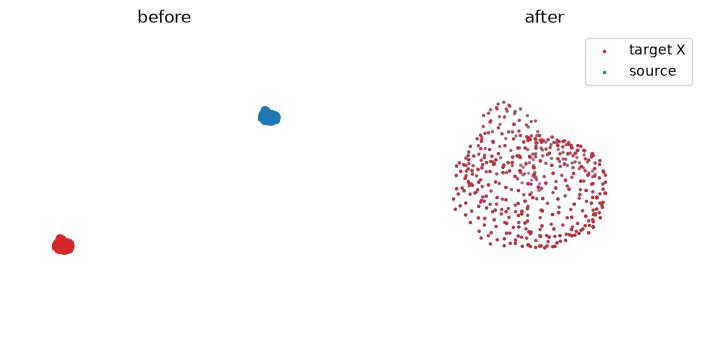

In [ ]:
fig = plt.figure(figsize=(9, 4))
for i, (title, source) in enumerate([("before", Y), ("after", TY)]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.scatter(*X.T, s=2, c="tab:red", label="target X")
    ax.scatter(*source.T, s=2, c="tab:blue", label="source")
    ax.set_title(title)
    ax.set_axis_off()
ax.legend(loc="upper right")
plt.show()

## Deformable registration

The two fish outlines differ by a non-rigid deformation. `beta` sets how far the motion of
a point spreads to its neighbors, and `alpha` how smooth the deformation is.
`normalize=True` measures both in units of the data's size, so the defaults work for data
in any unit.

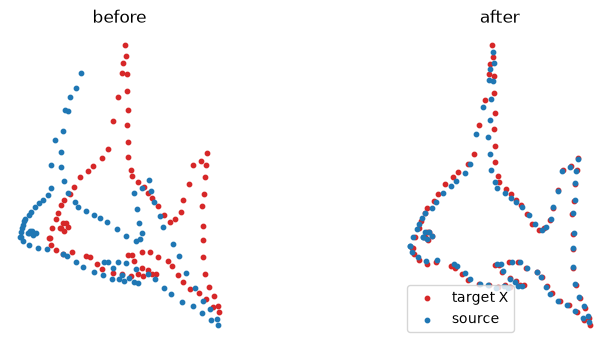

In [ ]:
X, Y = datasets.load_fish()
TY, (G, W) = DeformableRegistration(X, Y, alpha=2.0, beta=2.0, normalize=True).register()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, source) in zip(axes, [("before", Y), ("after", TY)]):
    ax.scatter(*X.T, s=10, c="tab:red", label="target X")
    ax.scatter(*source.T, s=10, c="tab:blue", label="source")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
axes[1].legend()
plt.show()

## GPUs and precision

Pass `device` (and optionally `dtype`) to compute on a GPU; NumPy inputs still give NumPy
outputs. Tensor inputs give tensor outputs on the same device. On Colab, choose
*Runtime > Change runtime type > GPU* to try CUDA.

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

X_t = torch.as_tensor(X, dtype=torch.float32, device=device)
Y_t = torch.as_tensor(Y, dtype=torch.float32, device=device)
TY_t, _ = DeformableRegistration(X_t, Y_t, normalize=True).register()
print(type(TY_t).__name__, TY_t.device, TY_t.dtype)
print("difference from float64 on the CPU:", float(np.abs(TY_t.cpu().numpy() - TY).max()))

Tensor cpu torch.float32
difference from float64 on the CPU: 1.6878103798134703e-05


## Batches

A leading batch dimension registers many pairs at once. Here one template fish (unbatched,
so it is shared) is registered to 16 rotated, shifted and noisy copies of itself. Each
pair keeps its own transform and stops at its own convergence.

In [ ]:
def rotation(angle):
    return np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])


rng = np.random.default_rng(0)
template = X
angles = rng.uniform(-0.6, 0.6, size=16)
Xs = np.stack(
    [
        template @ rotation(a).T + rng.normal(0, 0.3, 2) + rng.normal(0, 0.01, template.shape)
        for a in angles
    ]
)  # (16, 91, 2)

reg = RigidRegistration(Xs, template)
TY, (s, R, t) = reg.register()
recovered = np.arctan2(R[:, 0, 1], R[:, 0, 0])  # TY = s * template @ R + t
print(TY.shape, R.shape, t.shape)
print("all converged:", bool(reg.converged.all()), "| slowest pair:", reg.iteration, "iterations")
print("largest angle error (degrees):", np.degrees(np.abs(recovered - angles)).max().round(3))

(16, 91, 2) (16, 2, 2) (16, 2)
all converged: True | slowest pair: 24 iterations
largest angle error (degrees): 0.116


## Correspondences

After registration, `correspondences()` gives the most probable source point for every
target point: `X[n]` matches `Y[index[n]]`. Here the source is a shuffled, rotated copy of
the bunny, so the matches must undo the shuffle.

In [ ]:
X, _ = datasets.load_bunny()
order = rng.permutation(len(X))
angle = 0.3
Rz = np.array([[np.cos(angle), -np.sin(angle), 0], [np.sin(angle), np.cos(angle), 0], [0, 0, 1]])
Y = X[order] @ Rz + 0.1

reg = RigidRegistration(X, Y)
reg.register()
index = reg.correspondences()
print("correct matches:", np.mean(order[index] == np.arange(len(X))))

correct matches: 1.0


## Next steps

- [Documentation](https://cpd-pytorch.readthedocs.io/en/latest/): user guide and API.
- [Choosing parameters](https://cpd-pytorch.readthedocs.io/en/latest/guide/parameters/):
  outliers (`w`), units (`normalize`), smoothness (`alpha`, `beta`).
- [Large point sets](https://cpd-pytorch.readthedocs.io/en/latest/guide/large/): 100,000
  points with bounded memory.